<a href="https://colab.research.google.com/github/Ashfaq223/Ashfaq123/blob/main/Python_data_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing the Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


**Load the Dataset**

In [2]:
base_path = "Data set/"

orders     = pd.read_csv(base_path + "orders.csv")
deliveries = pd.read_csv(base_path + "deliveries.csv")
complaints = pd.read_csv(base_path + "complaints.csv")
customers  = pd.read_csv(base_path + "customers.csv")
drivers    = pd.read_csv(base_path + "drivers.csv")
vehicles   = pd.read_csv(base_path + "vehicles.csv")
incidents  = pd.read_csv(base_path + "incidents.csv")
hubs       = pd.read_csv(base_path + "hubs.csv")
app_events = pd.read_csv(base_path + "app_events.csv")

print("All files loaded successfully.")
print(f"Orders: {orders.shape}, Deliveries: {deliveries.shape}, App Events: {app_events.shape}")

All files loaded successfully.
Orders: (1250, 11), Deliveries: (950, 13), App Events: (640, 10)


**Cleaning the Data**

Before we move on to the analysis lets clean the dataset.

Inconsistent zones
Missing values
Timestamps that need to be converted to datetime format

In [3]:
# Fixing the zone

def clean_zone(value):
    if pd.isna(value):
        return value
    value = str(value).strip().lower()
    mapping = {
        "airport":   "Airport",
        "north":     "North",
        "south":     "South",
        "east":      "East",
        "west":      "West",
        "central":   "Central",
        "ctr":       "Central",
        "riverside": "Riverside"
    }
    return mapping.get(value, value.title())

orders["pickup_zone"]       = orders["pickup_zone"].apply(clean_zone)
orders["dropoff_zone"]      = orders["dropoff_zone"].apply(clean_zone)
drivers["base_zone"]        = drivers["base_zone"].apply(clean_zone)
customers["home_zone"]      = customers["home_zone"].apply(clean_zone)
vehicles["assigned_zone"]   = vehicles["assigned_zone"].apply(clean_zone)
app_events["zone_context"]  = app_events["zone_context"].apply(clean_zone)

In [4]:
# Filling the missing values

deliveries["customer_rating_post_delivery"].fillna(
    deliveries["customer_rating_post_delivery"].median(), inplace=True)

complaints["compensation_amount"].fillna(
    complaints["compensation_amount"].median(), inplace=True)

customers["loyalty_score"].fillna(
    customers["loyalty_score"].median(), inplace=True)

drivers["training_score"].fillna(
    drivers["training_score"].median(), inplace=True)

vehicles["battery_health_pct"].fillna(
    vehicles["battery_health_pct"].median(), inplace=True)

incidents["resolved_hours"].fillna(
    incidents["resolved_hours"].median(), inplace=True)

orders["booking_channel"].fillna("Unknown", inplace=True)
customers["preferred_channel"].fillna("Unknown", inplace=True)


/tmp/ipykernel_2247/2907329120.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  deliveries["customer_rating_post_delivery"].fillna(
/tmp/ipykernel_2247/2907329120.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [5]:
# app_events: order_id might have missing values. Lets fill it with a string value that says "No Order"

app_events["order_id"].fillna("No Order", inplace=True)

/tmp/ipykernel_2247/4172139377.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  app_events["order_id"].fillna("No Order", inplace=True)


In [6]:
# Converting the Timestamps

deliveries["dispatch_time"]          = pd.to_datetime(deliveries["dispatch_time"],          errors="coerce")
deliveries["delivery_completed_at"]  = pd.to_datetime(deliveries["delivery_completed_at"],  errors="coerce")
orders["order_created_at"]           = pd.to_datetime(orders["order_created_at"],           errors="coerce")
app_events["event_timestamp"]        = pd.to_datetime(app_events["event_timestamp"],        errors="coerce")

print("\nData cleaning complete.")
print(f"Remaining missing values - Deliveries: {deliveries.isnull().sum().sum()}")
print(f"Remaining missing values - Complaints: {complaints.isnull().sum().sum()}")


Data cleaning complete.
Remaining missing values - Deliveries: 19
Remaining missing values - Complaints: 0



**Feature Engineering**

We create new columns that will help us identify patterns that are not directly visible in the raw data.

1. Create delivery outcome flags

In [7]:
# Delivering delay flag

deliveries["is_failed"]  = deliveries["delivery_status"] == "Failed"
deliveries["is_delayed"] = deliveries["delivery_status"] == "Delayed"
deliveries["is_ontime"]  = deliveries["delivery_status"] == "OnTime"

2. Calculate delivery duration in hours

In [8]:
# Actual delivering duration (hours) where both timestamps exist

deliveries["delivery_duration_hrs"] = (
    deliveries["delivery_completed_at"] - deliveries["dispatch_time"]
).dt.total_seconds() / 3600


3. Detect timestamp errors

In [9]:
# Flag deliveries where duration is negative (data error)

deliveries["timestamp_error"] = deliveries["delivery_duration_hrs"] < 0

4. Calculate cost per kilometer

In [10]:
# Cost per km ratio

deliveries["cost_per_km"] = np.where(
    deliveries["route_distance_km"] > 0,
    deliveries["fuel_or_charge_cost"] / deliveries["route_distance_km"],
    np.nan
)

5. Create high latency flag in app events

In [11]:
# App event: flag high latency (above 800ms is considered slow)

app_events["high_latency"] = app_events["api_latency_ms"] > 800

6. Display all columns in deliveries dataset

In [12]:
print(deliveries.columns)

Index(['delivery_id', 'order_id', 'driver_id', 'vehicle_id', 'hub_id',
       'dispatch_time', 'delivery_completed_at', 'delivery_status',
       'route_distance_km', 'manual_route_override_count',
       'proof_of_completion_missing', 'customer_rating_post_delivery',
       'fuel_or_charge_cost', 'is_failed', 'is_delayed', 'is_ontime',
       'delivery_duration_hrs', 'timestamp_error', 'cost_per_km'],
      dtype='object')


7. Check whether timestamp_error column exists

In [13]:
if 'timestamp_error' in deliveries.columns:
    print(f"Timestamp errors found: {deliveries['timestamp_error'].sum()}")
else:
    print("Column 'timestamp_error' not found.")

Timestamp errors found: 64


In [14]:
print(deliveries.columns)

Index(['delivery_id', 'order_id', 'driver_id', 'vehicle_id', 'hub_id',
       'dispatch_time', 'delivery_completed_at', 'delivery_status',
       'route_distance_km', 'manual_route_override_count',
       'proof_of_completion_missing', 'customer_rating_post_delivery',
       'fuel_or_charge_cost', 'is_failed', 'is_delayed', 'is_ontime',
       'delivery_duration_hrs', 'timestamp_error', 'cost_per_km'],
      dtype='object')


In [15]:
deliveries["dispatch_time"] = pd.to_datetime(deliveries["dispatch_time"], errors="coerce")
deliveries["delivery_completed_at"] = pd.to_datetime(deliveries["delivery_completed_at"], errors="coerce")

In [16]:
# Duration
deliveries["delivery_duration_hrs"] = (
    deliveries["delivery_completed_at"] - deliveries["dispatch_time"]
).dt.total_seconds() / 3600

# Timestamp error
deliveries["timestamp_error"] = deliveries["delivery_duration_hrs"] < 0

**Advanced Analysis 1: Create Master Analytical Dataset**

In [49]:
#17 Advanced Analysis 1: Create Master Analytical Dataset
# (SS15: Show the merged analytical dataset preview and shape)

advanced_df = deliveries.merge(
    orders,
    on="order_id",
    how="left"
).merge(
    customers,
    on="customer_id",
    how="left"
).merge(
    drivers,
    on="driver_id",
    how="left"
).merge(
    vehicles,
    on="vehicle_id",
    how="left"
).merge(
    hubs,
    on="hub_id",
    how="left"
)

print("Advanced analytical dataset created successfully.")
print("Shape:", advanced_df.shape)

advanced_df.head()

Advanced analytical dataset created successfully.
Shape: (950, 55)


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,...,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version,hub_name,zone,hub_type,capacity_score
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,...,Central,2024-06-09 16:18:00,78.4,29849,Active,v2.2,Central Core,Central,Control,88
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,...,Airport,2025-09-17 08:52:00,68.6,78468,Active,v2.2,South Link,South,Dispatch,78
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,...,East,2025-12-09 16:47:00,55.9,15278,Active,v2.2,South Link,South,Dispatch,78
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,...,East,2025-06-05 13:40:00,83.3,85635,Active,v2.1,South Link,South,Dispatch,78
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,...,Riverside,2025-05-24 09:58:00,94.2,210683,InRepair,v2.0,North Exchange,North,Dispatch,82


**Advanced Analysis 2: Feature Engineering for Risk Classification**

  Risk Category  Number of Deliveries
0      Low Risk                   505
1   Medium Risk                   330
2     High Risk                   115


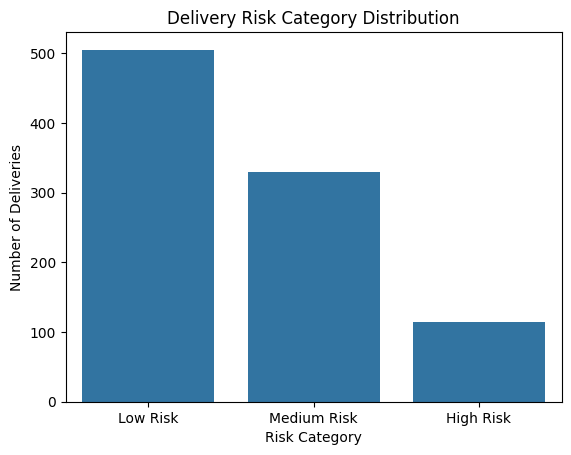

In [50]:
#18 Advanced Analysis 2: Feature Engineering for Risk Classification
# (SS16: Show engineered feature columns and risk category distribution)

advanced_df["delivery_risk_score"] = (
    advanced_df["is_failed"].astype(int) * 3 +
    advanced_df["is_delayed"].astype(int) * 2 +
    advanced_df["manual_route_override_count"].fillna(0) * 0.5 +
    advanced_df["timestamp_error"].astype(int) * 2
)

advanced_df["risk_category"] = pd.cut(
    advanced_df["delivery_risk_score"],
    bins=[-1, 1, 3, 100],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

risk_summary = advanced_df["risk_category"].value_counts().reset_index()
risk_summary.columns = ["Risk Category", "Number of Deliveries"]

print(risk_summary)

sns.barplot(data=risk_summary, x="Risk Category", y="Number of Deliveries")
plt.title("Delivery Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Deliveries")
plt.show()

**Advanced Analysis 3: Pattern Identification by Hub and Risk Category**

/tmp/ipykernel_2247/1694863576.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hub_risk = advanced_df.groupby(["hub_id", "risk_category"]).agg(


   hub_id risk_category  total_deliveries  avg_customer_rating  \
0     H01      Low Risk                72             4.254722   
1     H01   Medium Risk                48             3.503333   
2     H01     High Risk                16             3.001250   
3     H02      Low Risk                59             4.292373   
4     H02   Medium Risk                40             3.579750   
5     H02     High Risk                 7             3.207143   
6     H03      Low Risk                67             4.265672   
7     H03   Medium Risk                42             3.590000   
8     H03     High Risk                10             2.746000   
9     H04      Low Risk                70             4.305000   
10    H04   Medium Risk                42             3.540714   
11    H04     High Risk                15             3.155333   
12    H05      Low Risk                56             4.259107   
13    H05   Medium Risk                43             3.212326   
14    H05 

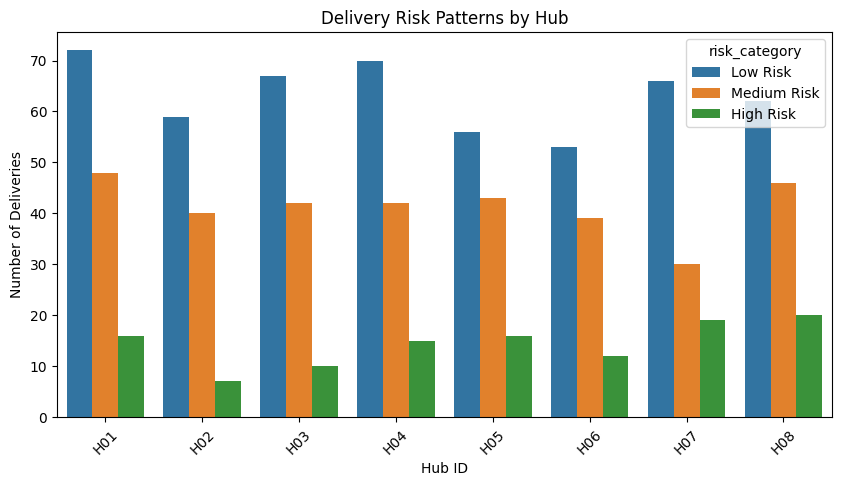

In [51]:
#19 Advanced Analysis 3: Pattern Identification by Hub and Risk Category
# (SS17: Show hub-level risk pattern table and chart)

hub_risk = advanced_df.groupby(["hub_id", "risk_category"]).agg(
    total_deliveries=("delivery_id", "count"),
    avg_customer_rating=("customer_rating_post_delivery", "mean"),
    avg_route_distance=("route_distance_km", "mean"),
    avg_cost_per_km=("cost_per_km", "mean")
).reset_index()

print(hub_risk)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=hub_risk,
    x="hub_id",
    y="total_deliveries",
    hue="risk_category"
)
plt.title("Delivery Risk Patterns by Hub")
plt.xlabel("Hub ID")
plt.ylabel("Number of Deliveries")
plt.xticks(rotation=45)
plt.show()

**Advanced Analysis 4: Outlier Detection in Delivery Duration and Cost Per KM**

Delivery duration outliers: 18
Cost per KM outliers: 69


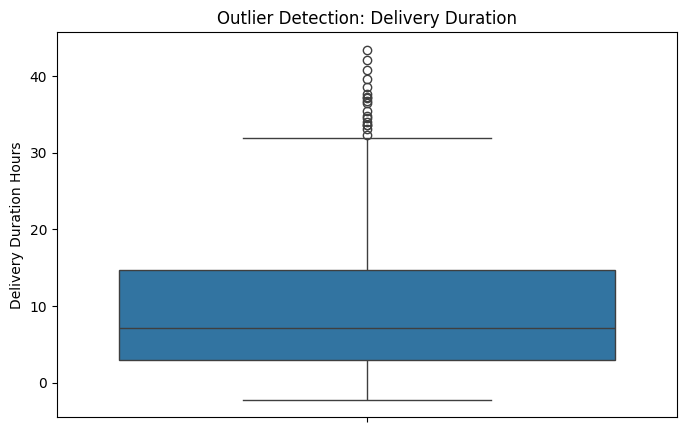

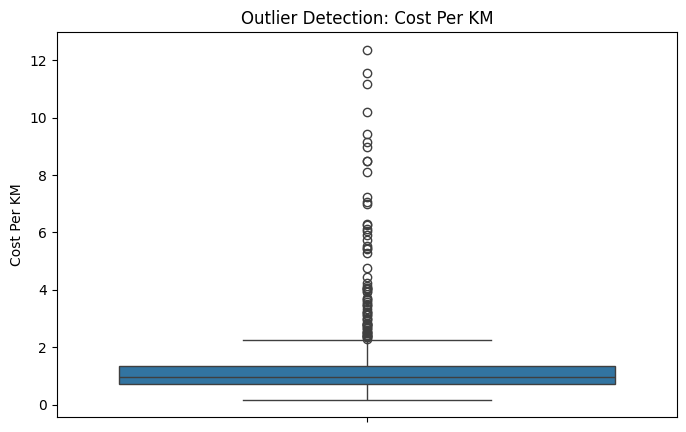

In [52]:
#20 Advanced Analysis 4: Outlier Detection in Delivery Duration and Cost Per KM
# (SS18: Capture outlier summary and boxplots)

duration_q1 = advanced_df["delivery_duration_hrs"].quantile(0.25)
duration_q3 = advanced_df["delivery_duration_hrs"].quantile(0.75)
duration_iqr = duration_q3 - duration_q1

duration_lower = duration_q1 - 1.5 * duration_iqr
duration_upper = duration_q3 + 1.5 * duration_iqr

advanced_df["duration_outlier"] = (
    (advanced_df["delivery_duration_hrs"] < duration_lower) |
    (advanced_df["delivery_duration_hrs"] > duration_upper)
)

cost_q1 = advanced_df["cost_per_km"].quantile(0.25)
cost_q3 = advanced_df["cost_per_km"].quantile(0.75)
cost_iqr = cost_q3 - cost_q1

cost_lower = cost_q1 - 1.5 * cost_iqr
cost_upper = cost_q3 + 1.5 * cost_iqr

advanced_df["cost_outlier"] = (
    (advanced_df["cost_per_km"] < cost_lower) |
    (advanced_df["cost_per_km"] > cost_upper)
)

print("Delivery duration outliers:", advanced_df["duration_outlier"].sum())
print("Cost per KM outliers:", advanced_df["cost_outlier"].sum())

plt.figure(figsize=(8, 5))
sns.boxplot(data=advanced_df, y="delivery_duration_hrs")
plt.title("Outlier Detection: Delivery Duration")
plt.ylabel("Delivery Duration Hours")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=advanced_df, y="cost_per_km")
plt.title("Outlier Detection: Cost Per KM")
plt.ylabel("Cost Per KM")
plt.show()

**Advanced **bold text** Analysis 5: Trend Analysis of Orders Over Time**

   order_date  total_orders  total_revenue  average_order_value
0  2024-01-01             5         245.94               49.188
1  2024-01-03             1         135.85              135.850
2  2024-01-04             1          11.54               11.540
3  2024-01-05             1          34.23               34.230
4  2024-01-06             1          32.16               32.160


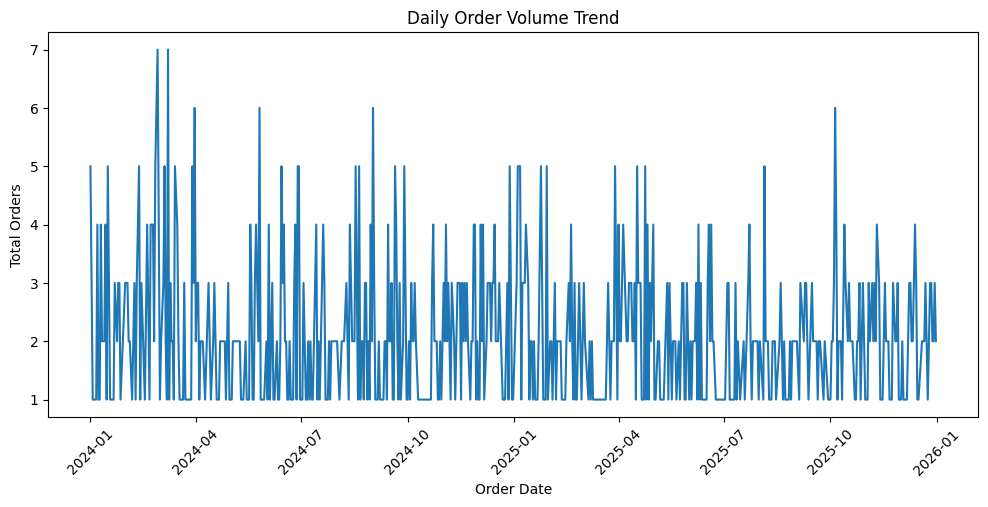

In [53]:
#21 Advanced Analysis 5: Trend Analysis of Orders Over Time
# (SS19: Capture daily order trend chart)

orders["order_date"] = orders["order_created_at"].dt.date

daily_orders = orders.groupby("order_date").agg(
    total_orders=("order_id", "count"),
    total_revenue=("order_value", "sum"),
    average_order_value=("order_value", "mean")
).reset_index()

print(daily_orders.head())

plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_orders, x="order_date", y="total_orders")
plt.title("Daily Order Volume Trend")
plt.xlabel("Order Date")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.show()

**Advanced Analysis 6: Simple Predictive Insight for Delivery Risk**

In [54]:
#22 Advanced Analysis 6: Simple Predictive Insight for Delivery Risk
# (SS20: Capture model accuracy and classification report)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model_df = advanced_df[[
    "route_distance_km",
    "manual_route_override_count",
    "fuel_or_charge_cost",
    "cost_per_km",
    "customer_rating_post_delivery",
    "vehicle_type",
    "risk_category"
]].dropna()

label_encoder_vehicle = LabelEncoder()
label_encoder_risk = LabelEncoder()

model_df["vehicle_type_encoded"] = label_encoder_vehicle.fit_transform(model_df["vehicle_type"])
model_df["risk_category_encoded"] = label_encoder_risk.fit_transform(model_df["risk_category"])

X = model_df[[
    "route_distance_km",
    "manual_route_override_count",
    "fuel_or_charge_cost",
    "cost_per_km",
    "customer_rating_post_delivery",
    "vehicle_type_encoded"
]]

y = model_df["risk_category_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

risk_model = RandomForestClassifier(random_state=42)
risk_model.fit(X_train, y_train)

y_pred = risk_model.predict(X_test)

print("Model Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 68.42 %

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.55      0.67        22
           1       0.69      0.82      0.75        94
           2       0.64      0.55      0.59        74

    accuracy                           0.68       190
   macro avg       0.73      0.64      0.67       190
weighted avg       0.69      0.68      0.68       190

